# I.3

Meta Nacional I.3 Al 2026, se habrán reconocido como Humedales Urbanos protegidos entre 14.000 y 17.000 hectáreas de humedales a lo largo del territorio nacional, desde la aprobación de la Ley 21.202 de Humedales Urbanos, para su incorporación como infraestructura ecológica en los instrumentos de planificación territorial.

## Descarga de datos

Descargar capa de humedales urbanos:
[https://apps.mma.gob.cl/visorsimbio](https://apps.mma.gob.cl/visorsimbio
)

![download_layer](download_layer.png)

## Sumar superficie de cada humedal

In [1]:
import geopandas as gpd
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np

In [2]:
data = gpd.read_file("zip://data/raw/HumedalesUrbanosDeclarados_shapefile_202510030400.zip")
data = data.to_crs(epsg=32719)
data

,COD_HUM_M,HECTAREAS,PROCESO,RESOLUCION,URL_RES_BC,NOMBRE,COMUNA,PROVINCIA,REGION,Shape_Leng,Shape_Area,geometry
0,HU-0012,1.005898,O,R.E. N°0787/2021,http://bcn.cl/2ul3k,Aguada La Chimba,ANTOFAGASTA,ANTOFAGASTA,REGIÓN DE ANTOFAGASTA,888.750651,1.005601e+04,"MULTIPOLYGON (((357138.004 7393358.996, 357142..."
1,HU-0031,2.809060,O,R.E. N°0990/2021,http://bcn.cl/2svqw,Baños Morales,SAN JOSÉ DE MAIPO,CORDILLERA,REGIÓN METROPOLITANA DE SANTIAGO,1482.898397,2.807481e+04,"POLYGON ((401725.46 6257146.651, 401725.339 62..."
2,HU-0029,279.376802,O,R.E. N°0982/2021,http://bcn.cl/2ul4c,Bucalemu,PAREDONES,CARDENAL CARO,REGIÓN DEL LIBERTADOR GENERAL BERNARDO O'HIGGINS,21404.983258,2.796775e+06,"MULTIPOLYGON (((225892.531 6163974.988, 225864..."
3,HU-0010,37.247461,M,RE N° 784/ 2021,http://bcn.cl/2rcl5,Circuito Humedales Pudeto Bajo,ANCUD,CHILOÉ,REGIÓN DE LOS LAGOS,7589.915451,3.736260e+05,"MULTIPOLYGON (((102253.066 5352074.501, 102278..."
4,HU-0027,6.617904,O,RE N° 921/ 2021,http://bcn.cl/2sspa,El Avellano,LOS ÁNGELES,BIOBÍO,REGIÓN DEL BIOBÍO,1746.500679,6.626825e+04,"POLYGON ((204524.596 5851175.37, 204517.271 58..."
...,...,...,...,...,...,...,...,...,...,...,...,...
120,HU-0134,16.895248,M,R.E. N°5196/2025,None,Estero Reñaca,VIÑA DEL MAR,VALPARAÍSO,REGIÓN DE VALPARAÍSO,66252.868406,1.690460e+05,"MULTIPOLYGON (((265089.997 6349750.441, 265086..."
121,HU-0135,2321.494370,M,R.E. N°6104/2025,https://bcn.cl/kevvty,Humedal urbano Río Maipo de Melipilla,MELIPILLA,MELIPILLA,REGIÓN METROPOLITANA DE SANTIAGO,88512.298662,2.322176e+07,"MULTIPOLYGON (((302928.8 6269779.974, 302945.6..."
122,HU-0136,254.016580,M,R.E. N°6073/2025,None,Estero del Arrayán y sus afluentes,LO BARNECHEA,SANTIAGO,REGIÓN METROPOLITANA DE SANTIAGO,255825.254092,2.539215e+06,"POLYGON ((372213.023 6335374.002, 372207.336 6..."
123,HU-0104,0.328944,M,R.E. N°1275/2023,https://bcn.cl/3gsx9,Parque Mirasol,PUERTO MONTT,LLANQUIHUE,REGIÓN DE LOS LAGOS,474.985016,3.295764e+03,"POLYGON ((167556.789 5400923.593, 167564.493 5..."


Estandarizar regiones

In [3]:
REGION = {
    'REGIÓN DE TARAPACÁ': "TA",
    'REGIÓN DE ANTOFAGASTA': "AN",
    'REGIÓN DE ATACAMA': "AT",
    'REGIÓN DE COQUIMBO': "CO",
    'REGIÓN DE VALPARAÍSO': "VA",
    'REGIÓN METROPOLITANA DE SANTIAGO': "RM",
    "REGIÓN DEL LIBERTADOR GENERAL BERNARDO O'HIGGINS": "LI",
    'REGIÓN DEL MAULE': "ML",
    'REGIÓN DEL ÑUBLE': "NB",
    'REGIÓN DEL BIOBÍO': "BI",
    'REGIÓN DE LA ARAUCANÍA': "AR",
    'REGIÓN DE LOS RÍOS': "LR",
    'REGIÓN DE LOS LAGOS': "LL",
    'REGIÓN DE AYSÉN DEL GENERAL CARLOS IBÁÑEZ DEL CAMPO': "AI",
    'REGIÓN DE MAGALLANES Y DE LA ANTÁRTICA CHILENA': "MA",
}

In [4]:
data["COD_REG"] = data["REGION"].map(REGION)
data

,COD_HUM_M,HECTAREAS,PROCESO,RESOLUCION,URL_RES_BC,NOMBRE,COMUNA,PROVINCIA,REGION,Shape_Leng,Shape_Area,geometry,COD_REG
0,HU-0012,1.005898,O,R.E. N°0787/2021,http://bcn.cl/2ul3k,Aguada La Chimba,ANTOFAGASTA,ANTOFAGASTA,REGIÓN DE ANTOFAGASTA,888.750651,1.005601e+04,"MULTIPOLYGON (((357138.004 7393358.996, 357142...",AN
1,HU-0031,2.809060,O,R.E. N°0990/2021,http://bcn.cl/2svqw,Baños Morales,SAN JOSÉ DE MAIPO,CORDILLERA,REGIÓN METROPOLITANA DE SANTIAGO,1482.898397,2.807481e+04,"POLYGON ((401725.46 6257146.651, 401725.339 62...",RM
2,HU-0029,279.376802,O,R.E. N°0982/2021,http://bcn.cl/2ul4c,Bucalemu,PAREDONES,CARDENAL CARO,REGIÓN DEL LIBERTADOR GENERAL BERNARDO O'HIGGINS,21404.983258,2.796775e+06,"MULTIPOLYGON (((225892.531 6163974.988, 225864...",LI
3,HU-0010,37.247461,M,RE N° 784/ 2021,http://bcn.cl/2rcl5,Circuito Humedales Pudeto Bajo,ANCUD,CHILOÉ,REGIÓN DE LOS LAGOS,7589.915451,3.736260e+05,"MULTIPOLYGON (((102253.066 5352074.501, 102278...",LL
4,HU-0027,6.617904,O,RE N° 921/ 2021,http://bcn.cl/2sspa,El Avellano,LOS ÁNGELES,BIOBÍO,REGIÓN DEL BIOBÍO,1746.500679,6.626825e+04,"POLYGON ((204524.596 5851175.37, 204517.271 58...",BI
...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,HU-0134,16.895248,M,R.E. N°5196/2025,None,Estero Reñaca,VIÑA DEL MAR,VALPARAÍSO,REGIÓN DE VALPARAÍSO,66252.868406,1.690460e+05,"MULTIPOLYGON (((265089.997 6349750.441, 265086...",VA
121,HU-0135,2321.494370,M,R.E. N°6104/2025,https://bcn.cl/kevvty,Humedal urbano Río Maipo de Melipilla,MELIPILLA,MELIPILLA,REGIÓN METROPOLITANA DE SANTIAGO,88512.298662,2.322176e+07,"MULTIPOLYGON (((302928.8 6269779.974, 302945.6...",RM
122,HU-0136,254.016580,M,R.E. N°6073/2025,None,Estero del Arrayán y sus afluentes,LO BARNECHEA,SANTIAGO,REGIÓN METROPOLITANA DE SANTIAGO,255825.254092,2.539215e+06,"POLYGON ((372213.023 6335374.002, 372207.336 6...",RM
123,HU-0104,0.328944,M,R.E. N°1275/2023,https://bcn.cl/3gsx9,Parque Mirasol,PUERTO MONTT,LLANQUIHUE,REGIÓN DE LOS LAGOS,474.985016,3.295764e+03,"POLYGON ((167556.789 5400923.593, 167564.493 5...",LL


Datos calculados

In [5]:
data_region = pd.DataFrame(
    list(REGION.items()),
    columns=["Región", "Código Región"]
)
data_region["geometry"] = None
data_region["Hectáreas"] = 0.0
data_region["Hectáreas (geometría)"] = 0.0
data_region["Número de humedales"] = 0

In [6]:
for region in REGION.values():
    tmp = data[data["COD_REG"] == region]
    tmp_geometry = tmp.geometry.union_all()
    cur_index = data_region[data_region["Código Región"] == region].index[0]
    data_region.loc[cur_index, "geometry"] = tmp_geometry
    data_region.loc[cur_index, "Hectáreas"] = tmp["HECTAREAS"].sum()
    data_region.loc[cur_index, "Hectáreas (geometría)"] = tmp_geometry.area / 10000
    data_region.loc[cur_index, "Número de humedales"] = len(tmp)
    del tmp, tmp_geometry

data_region

/opt/miniconda3/envs/7nr/lib/python3.13/site-packages/shapely/set_operations.py:553: RuntimeWarning: invalid value encountered in unary_union
  return lib.unary_union(collections, **kwargs)


,Región,Código Región,geometry,Hectáreas,Hectáreas (geometría),Número de humedales
0,REGIÓN DE TARAPACÁ,TA,"POLYGON ((379881.2673000004 7751351.8057, 3800...",132.612247,132.552911,1
1,REGIÓN DE ANTOFAGASTA,AN,MULTIPOLYGON (((368475.6813000003 7385950.1118...,1033.411963,1032.627912,4
2,REGIÓN DE ATACAMA,AT,MULTIPOLYGON (((323693.22140000015 6839607.418...,100.807130,100.800859,2
3,REGIÓN DE COQUIMBO,CO,"POLYGON ((262177.99990000017 6441502, 262181.9...",5.899871,5.903399,1
4,REGIÓN DE VALPARAÍSO,VA,MULTIPOLYGON (((256609.43090000004 6278331.825...,1082.262354,1082.758936,21
5,REGIÓN METROPOLITANA DE SANTIAGO,RM,MULTIPOLYGON (((279739.0220999997 6261686.7248...,6001.755022,6002.254365,14
6,REGIÓN DEL LIBERTADOR GENERAL BERNARDO O'HIGGINS,LI,MULTIPOLYGON (((223047.2751000002 6161067.2023...,380.755942,381.145261,5
7,REGIÓN DEL MAULE,ML,"POLYGON ((257338.17750000022 6078380.7958, 257...",348.412700,348.639730,1
8,REGIÓN DEL ÑUBLE,NB,MULTIPOLYGON (((193223.17090000026 5925784.039...,1117.538007,1119.581066,7
9,REGIÓN DEL BIOBÍO,BI,MULTIPOLYGON (((113207.42109999992 5806359.772...,1033.928526,1036.606200,22


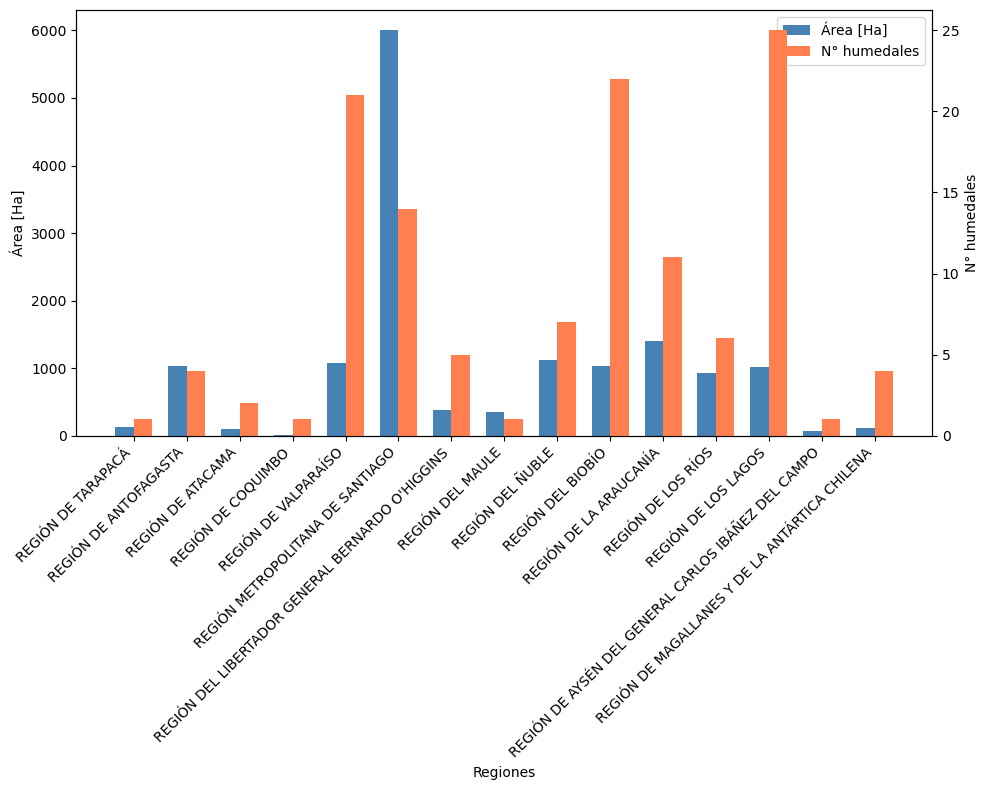

In [8]:
fig, ax = plt.subplots(figsize=(10, 8))

position = np.arange(len(data_region))
width = 0.35

area_bar = ax.bar(position - width / 2, data_region["Hectáreas (geometría)"], width, label="Área [Ha]", color="steelblue")
ax.set_xlabel("Regiones")
ax.set_ylabel("Área [Ha]")

ax2 = ax.twinx()
number_bar = ax2.bar(position + width / 2, data_region["Número de humedales"], width, label="N° humedales", color="coral")
ax2.set_ylabel("N° humedales")

ax.set_xticks(position)
ax.set_xticklabels(data_region["Región"], rotation=45, ha='right')

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()